In [1]:
import sys
!{sys.executable} -m pip install xgboost --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [3]:
# Data loading
# ── Global config ────────────────────────────────────────────────────────────
DATA_PATH   = r'C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv'
SERVER_IDS  = [1, 2, 3]

WORK_HOURS  = list(range(9, 19))       # 9,10,...,18  →  10 steps
LOOKBACK    = 24                        # hours of context
HORIZON     = len(WORK_HOURS)
INFER_DATE  = '2026-06-11'             # forecast target date

print(f'Servers      : {SERVER_IDS}')
print(f'Working hours: {WORK_HOURS[0]:02d}:00 → {WORK_HOURS[-1]:02d}:00  ({HORIZON} steps)')
print(f'Lookback     : {LOOKBACK} hours')
print(f'Forecast date: {INFER_DATE}')

Servers      : [1, 2, 3]
Working hours: 09:00 → 18:00  (10 steps)
Lookback     : 24 hours
Forecast date: 2026-06-11


In [4]:
# ── Load raw CSV ──────────────────────────────────────────────────────────────
df_all = pd.read_csv(DATA_PATH)
df_all['ts'] = pd.to_datetime(df_all['ts'], format='mixed', utc=True)
df_all = df_all.sort_values(['host_id', 'ts'])

server_names = df_all[['host_id','hostName']].drop_duplicates().set_index('host_id')['hostName'].to_dict()
print('Loaded rows per server:')
for sid, name in server_names.items():
    n = len(df_all[df_all['host_id']==sid])
    print(f'  Server {sid} ({name}): {n:,} rows')

Loaded rows per server:
  Server 1 (10.10.10.65): 24,750 rows
  Server 2 (10.10.10.150): 24,751 rows
  Server 3 (10.10.10.2): 24,751 rows


#### Feature engineering and dataset building

In [5]:
def resample_hourly(df_server):
    """Aggregate 5-min rows → hourly means + spike envelope."""
    hourly = df_server.set_index('ts').resample('1h').agg(
        cpu_usage_pct         = ('cpu_usage_pct',         'mean'),
        cpu_min               = ('cpu_usage_pct',         'min'),
        cpu_max               = ('cpu_usage_pct',         'max'),
        cpu_std               = ('cpu_usage_pct',         'std'),
        memory_usage_pct      = ('memory_usage_pct',      'mean'),
        power_kw              = ('power_kw',              'mean'),
        cpu_temp_c            = ('cpu_temp_c',            'mean'),
        inlet_temp_c          = ('inlet_temp_c',          'mean'),
        resource_stress_index = ('resource_stress_index', 'mean'),
    ).dropna()
    return hourly


def add_features(hourly):
    """Add temporal, lag, and rolling features to an hourly DataFrame."""
    h = hourly.copy()
    # Time features
    h['hour_of_day'] = h.index.hour
    h['day_of_week'] = h.index.dayofweek
    h['is_weekend']  = (h['day_of_week'] >= 5).astype(int)
    h['hour_sin']    = np.sin(2 * np.pi * h['hour_of_day'] / 24)
    h['hour_cos']    = np.cos(2 * np.pi * h['hour_of_day'] / 24)
    h['dow_sin']     = np.sin(2 * np.pi * h['day_of_week'] / 7)
    h['dow_cos']     = np.cos(2 * np.pi * h['day_of_week'] / 7)
    # CPU lags
    for lag in range(1, LOOKBACK + 1):
        h[f'cpu_lag_{lag}'] = h['cpu_usage_pct'].shift(lag)
    # Weekly anchors
    h['cpu_lag_1w']        = h['cpu_usage_pct'].shift(168)
    h['cpu_lag_2w']        = h['cpu_usage_pct'].shift(336)
    h['cpu_vs_last_week']  = h['cpu_usage_pct'] - h['cpu_lag_1w']
    # Rolling context
    h['roll_mean_8h']  = h['cpu_usage_pct'].shift(1).rolling(8).mean()
    h['roll_mean_24h'] = h['cpu_usage_pct'].shift(1).rolling(24).mean()
    h['roll_std_8h']   = h['cpu_usage_pct'].shift(1).rolling(8).std()
    # Trend slope (6h window)
    x = np.arange(6)
    h['cpu_trend_6h'] = (
        h['cpu_usage_pct'].shift(1)
        .rolling(6)
        .apply(lambda y: np.polyfit(x, y, 1)[0], raw=True)
    )
    # System context lags
    for col in ['memory_usage_pct','power_kw','cpu_temp_c','inlet_temp_c','resource_stress_index']:
        h[f'{col}_lag1'] = h[col].shift(1)
    h.dropna(inplace=True)
    return h


FEATURE_COLS = (
    [f'cpu_lag_{i}' for i in range(1, LOOKBACK + 1)] +
    ['cpu_lag_1w', 'cpu_lag_2w', 'cpu_vs_last_week',
     'roll_mean_8h', 'roll_mean_24h', 'roll_std_8h', 'cpu_trend_6h',
     'cpu_min', 'cpu_max', 'cpu_std',
     'memory_usage_pct_lag1', 'power_kw_lag1', 'cpu_temp_c_lag1',
     'inlet_temp_c_lag1', 'resource_stress_index_lag1',
     'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
     'hour_of_day', 'day_of_week', 'is_weekend']
)
TARGET_COLS = [f'cpu_t{h:02d}' for h in WORK_HOURS]
print(f'Feature columns : {len(FEATURE_COLS)}')
print(f'Target columns  : {TARGET_COLS}')

Feature columns : 46
Target columns  : ['cpu_t09', 'cpu_t10', 'cpu_t11', 'cpu_t12', 'cpu_t13', 'cpu_t14', 'cpu_t15', 'cpu_t16', 'cpu_t17', 'cpu_t18']


In [6]:
def build_day_dataset(hourly_feat):
    """Build one row per day: 8 AM features → 9-17 h targets."""
    records = []
    for date in sorted(pd.Series(hourly_feat.index.date).unique()):
        day = hourly_feat[hourly_feat.index.date == date]
        pred_rows = day[day['hour_of_day'] == 8]
        if pred_rows.empty:
            continue
        pred_row = pred_rows.iloc[-1]
        # Collect targets
        target_vals, ok = {}, True
        for h in WORK_HOURS:
            t = day[day['hour_of_day'] == h]
            if t.empty: ok = False; break
            target_vals[f'cpu_t{h:02d}'] = t.iloc[0]['cpu_usage_pct']
        if not ok:
            continue
        row = {col: pred_row[col] for col in FEATURE_COLS}
        row.update(target_vals)
        row['pred_date'] = date
        records.append(row)
    return pd.DataFrame(records)


def train_model(dataset):
    """Chronological 80/20 split + MultiOutputRegressor(XGBoost)."""
    split = int(len(dataset) * 0.8)
    train, test = dataset.iloc[:split], dataset.iloc[split:]
    X_tr, Y_tr = train[FEATURE_COLS], train[TARGET_COLS]
    X_te, Y_te = test[FEATURE_COLS],  test[TARGET_COLS]
    base = XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.85,
        min_child_weight=3, gamma=0.1, reg_lambda=1.5,
        tree_method='hist', random_state=42
    )
    model = MultiOutputRegressor(base, n_jobs=-1)
    model.fit(X_tr, Y_tr)
    preds = model.predict(X_te)
    return model, X_tr, Y_tr, X_te, Y_te, preds, train, test

print('Helper functions ready.')

Helper functions ready.


#### Train and evaluate

In [9]:
server_results = {}   # keyed by host_id

for sid in SERVER_IDS:
    name = server_names[sid]
    print(f"\n{'='*55}")
    print(f'  SERVER {sid}  |  {name}')
    print(f"{'='*55}")

    # 1. Filter + resample
    df_s   = df_all[df_all['host_id'] == sid].copy()
    hourly = resample_hourly(df_s)
    hourly = add_features(hourly)
    print(f'  Hourly rows after feature engineering: {len(hourly):,}')

    # 2. Build day-level dataset
    dataset = build_day_dataset(hourly)
    print(f'  Day-level samples (train+test): {len(dataset)}')

    # 3. Train
    model, X_tr, Y_tr, X_te, Y_te, preds, train_df, test_df = train_model(dataset)
    print(f'  Train days: {len(train_df)}   Test days: {len(test_df)}')

    # 4. Metrics
    metrics = []
    for i, h in enumerate(WORK_HOURS):
        col  = f'cpu_t{h:02d}'
        mae  = mean_absolute_error(Y_te[col], preds[:, i])
        rmse = np.sqrt(mean_squared_error(Y_te[col], preds[:, i]))
        r2   = r2_score(Y_te[col], preds[:, i])
        metrics.append({'Hour': f'{h:02d}:00', 'MAE': round(mae,3),
                         'RMSE': round(rmse,3), 'R2': round(r2,3)})
    metrics_df = pd.DataFrame(metrics)
    print(f'  Mean MAE : {metrics_df["MAE"].mean():.3f}')
    print(f'  Mean RMSE: {metrics_df["RMSE"].mean():.3f}')

    server_results[sid] = {
        'name'      : name,
        'hourly'    : hourly,
        'dataset'   : dataset,
        'model'     : model,
        'X_te'      : X_te,
        'Y_te'      : Y_te,
        'preds'     : preds,
        'test_df'   : test_df,
        'metrics_df': metrics_df,
    }

print('\nAll 3 servers trained successfully.')


  SERVER 1  |  10.10.10.65
  Hourly rows after feature engineering: 1,337
  Day-level samples (train+test): 55
  Train days: 44   Test days: 11
  Mean MAE : 0.989
  Mean RMSE: 1.257

  SERVER 2  |  10.10.10.150
  Hourly rows after feature engineering: 1,337
  Day-level samples (train+test): 55
  Train days: 44   Test days: 11
  Mean MAE : 0.493
  Mean RMSE: 0.686

  SERVER 3  |  10.10.10.2
  Hourly rows after feature engineering: 1,337
  Day-level samples (train+test): 55
  Train days: 44   Test days: 11
  Mean MAE : 0.899
  Mean RMSE: 1.217

All 3 servers trained successfully.


In [10]:
# June 11 working hours
from datetime import date as dt_date

INFER_CONTEXT_DATE = '2026-06-10'   # 8 AM row used as prediction context
june11_forecasts   = {}             # store forecasts for the comparison plot

for sid in SERVER_IDS:
    r      = server_results[sid]
    hourly = r['hourly']
    model  = r['model']
    name   = r['name']

    # Get the 8 AM row on June 10
    context_rows = hourly[
        (hourly.index.date == pd.Timestamp(INFER_CONTEXT_DATE).date()) &
        (hourly['hour_of_day'] == 8)
    ]
    if context_rows.empty:
        print(f'Server {sid}: No 8 AM row found on {INFER_CONTEXT_DATE}. Skipping.')
        continue

    X_infer  = pd.DataFrame([context_rows.iloc[-1][FEATURE_COLS]])
    forecast = model.predict(X_infer)[0]   # shape (9,)
    june11_forecasts[sid] = forecast

    print(f'\nServer {sid} | {name}  — June 11 Forecast')
    print(f"{'Hour':<8} {'CPU %':>8}")
    print('-' * 18)
    for h, val in zip(WORK_HOURS, forecast):
        print(f'  {h:02d}:00   {val:>7.2f}%')


Server 1 | 10.10.10.65  — June 11 Forecast
Hour        CPU %
------------------
  09:00      6.50%
  10:00      4.43%
  11:00      7.34%
  12:00      5.28%
  13:00      6.32%
  14:00      3.33%
  15:00      3.15%
  16:00      3.40%
  17:00      3.19%
  18:00      3.08%

Server 2 | 10.10.10.150  — June 11 Forecast
Hour        CPU %
------------------
  09:00      3.26%
  10:00      1.98%
  11:00      2.27%
  12:00      1.95%
  13:00      1.94%
  14:00      2.14%
  15:00      2.20%
  16:00      1.92%
  17:00      1.75%
  18:00      1.79%

Server 3 | 10.10.10.2  — June 11 Forecast
Hour        CPU %
------------------
  09:00     27.69%
  10:00     27.70%
  11:00     27.91%
  12:00     27.88%
  13:00     27.87%
  14:00     28.00%
  15:00     28.11%
  16:00     27.55%
  17:00     28.11%
  18:00     28.16%


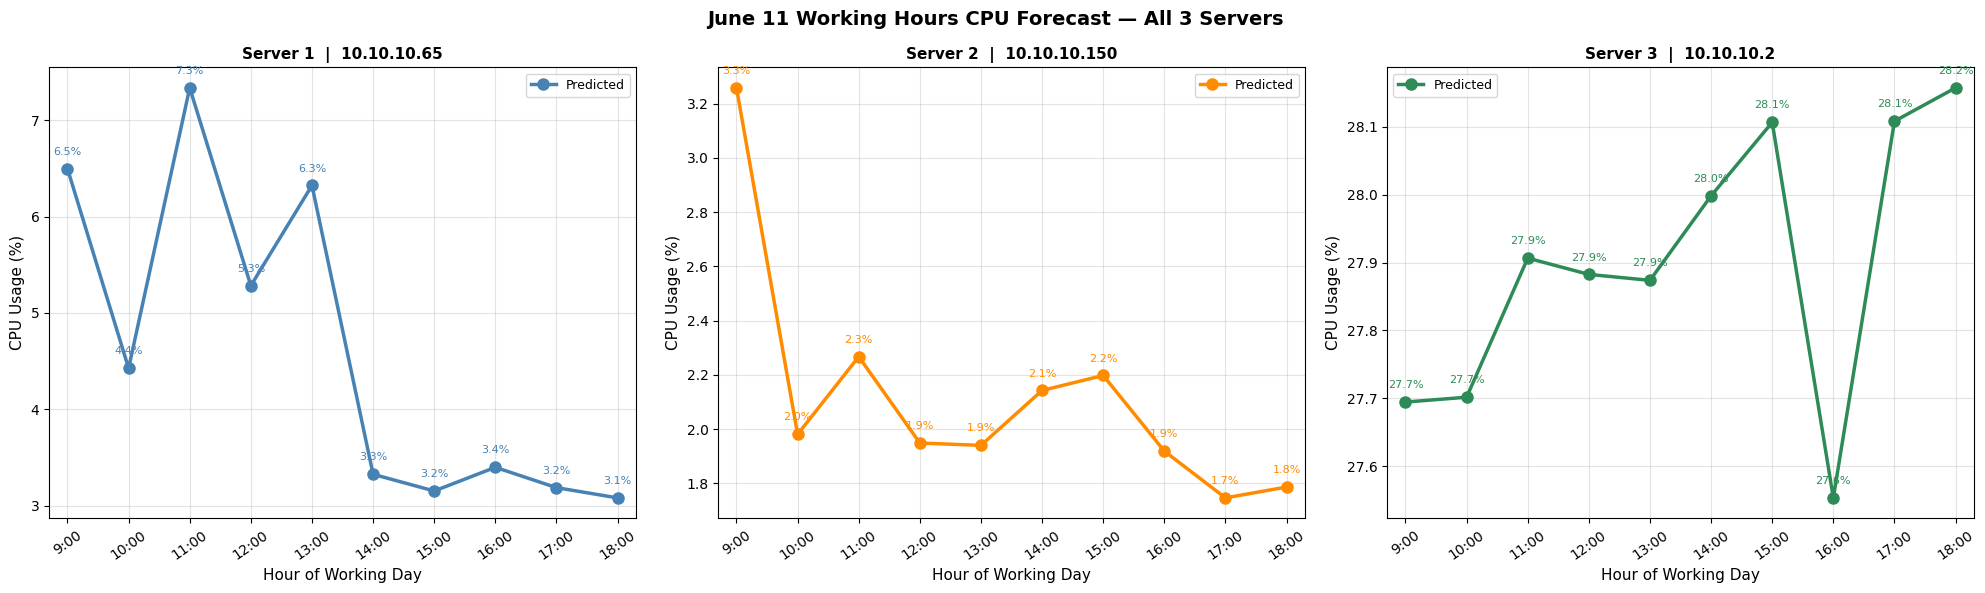

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

colors = ['steelblue', 'darkorange', 'seagreen']

for ax, sid, color in zip(axes, SERVER_IDS, colors):
    if sid not in june11_forecasts:
        ax.set_visible(False)
        continue

    forecast = june11_forecasts[sid]
    name     = server_results[sid]['name']

    ax.plot(WORK_HOURS, forecast, color=color, marker='o', lw=2.5,
            markersize=8, label='Predicted')

    # Annotate each point with its value
    for h, val in zip(WORK_HOURS, forecast):
        ax.annotate(f'{val:.1f}%',
                    xy=(h, val), xytext=(0, 10),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color)

    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels([f'{h}:00' for h in WORK_HOURS], rotation=35)
    ax.set_xlabel('Hour of Working Day', fontsize=11)
    ax.set_ylabel('CPU Usage (%)', fontsize=11)
    ax.set_title(f'Server {sid}  |  {name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
    ax.set_xlim(WORK_HOURS[0]-0.3, WORK_HOURS[-1]+0.3)

fig.suptitle('June 11 Working Hours CPU Forecast — All 3 Servers',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

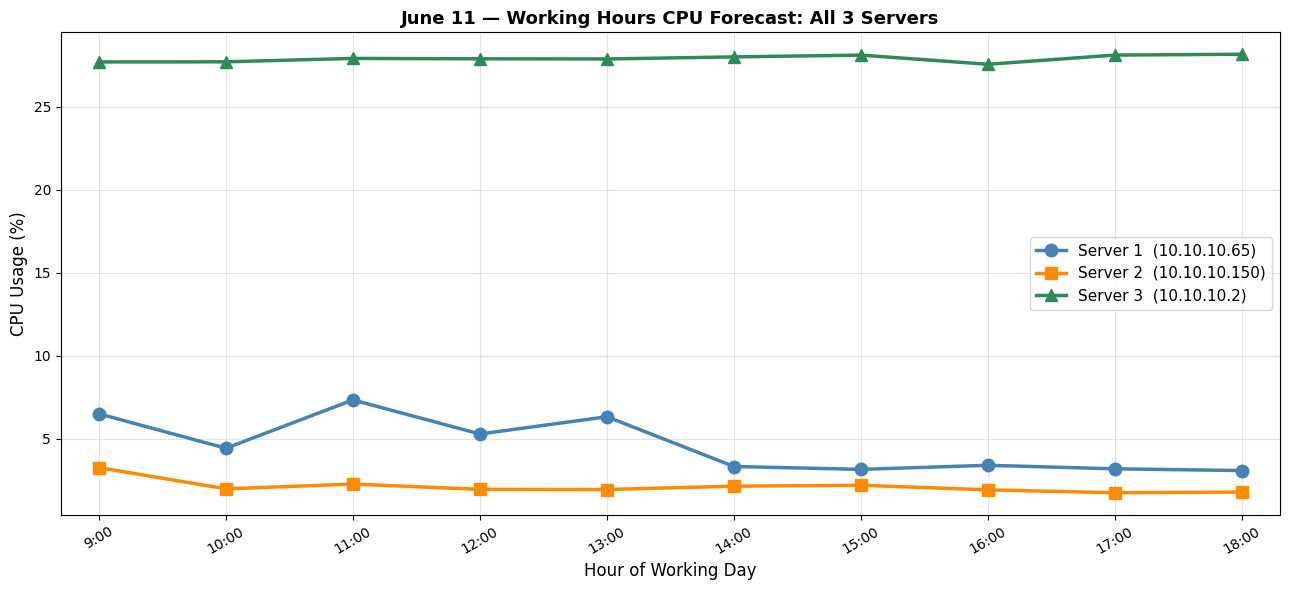

In [12]:
fig, ax = plt.subplots(figsize=(13, 6))

colors  = {1: 'steelblue', 2: 'darkorange', 3: 'seagreen'}
markers = {1: 'o',         2: 's',          3: '^'}

for sid in SERVER_IDS:
    if sid not in june11_forecasts:
        continue
    name     = server_results[sid]['name']
    forecast = june11_forecasts[sid]
    ax.plot(WORK_HOURS, forecast,
            color=colors[sid], marker=markers[sid], lw=2.5, markersize=9,
            label=f'Server {sid}  ({name})')

ax.set_xticks(WORK_HOURS)
ax.set_xticklabels([f'{h}:00' for h in WORK_HOURS], rotation=30)
ax.set_xlabel('Hour of Working Day', fontsize=12)
ax.set_ylabel('CPU Usage (%)', fontsize=12)
ax.set_title('June 11 — Working Hours CPU Forecast: All 3 Servers', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
ax.set_xlim(WORK_HOURS[0]-0.3, WORK_HOURS[-1]+0.3)
plt.tight_layout()
plt.show()

In [13]:
# June 11 forecast memory
rows = []
for h in WORK_HOURS:
    row = {'Hour': f'{h:02d}:00'}
    for sid in SERVER_IDS:
        if sid in june11_forecasts:
            i = WORK_HOURS.index(h)
            row[f'Server {sid} ({server_names[sid]})'] = f"{june11_forecasts[sid][i]:.2f}%"
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Hour')
print('June 11 Working Hours Forecast — All Servers')
print('=' * 60)
print(summary.to_string())

June 11 Working Hours Forecast — All Servers
      Server 1 (10.10.10.65) Server 2 (10.10.10.150) Server 3 (10.10.10.2)
Hour                                                                      
09:00                  6.50%                   3.26%                27.69%
10:00                  4.43%                   1.98%                27.70%
11:00                  7.34%                   2.27%                27.91%
12:00                  5.28%                   1.95%                27.88%
13:00                  6.32%                   1.94%                27.87%
14:00                  3.33%                   2.14%                28.00%
15:00                  3.15%                   2.20%                28.11%
16:00                  3.40%                   1.92%                27.55%
17:00                  3.19%                   1.75%                28.11%
18:00                  3.08%                   1.79%                28.16%
